# Cubo Gelatinoso
**Professor orientador:** Dr. Daniel R. Cassar

**Aluno:** Gustavo Junqueira Colas

**Disciplina:** Aprendizado de Máquina

<h2 id="introducao">Introdução</h2>


<div style="text-align: justify; max-width: 96%">
Primeiramente, é essencial entender o que é o <strong style = "font-size: 1.2em">algortimo <i>&#119896;-NN</i></strong>. Esse algoritmo (também chamado de "&#119896;-vizinhos mais próximos") basea-se na hipótese de que dados similares deverão ocupar regiões similares no espaço dos atributos. 

A lógica que fundamenta esse algoritmo é relativamente simples: como entrada, recebe-se um exemplo qualquer e averigua a distância desse exemplo com relação aos exemplos que já estão na sua memória (estes últimos são o que se chama de "vizinhos"). Em seguida, existem dois tipos de previsão, sendo elas
    <ul>
    <li><b>problema de classificação </b> - quando o alvo a ser predito é uma variável categórica, contexto no qual o resultado será a moda da classificação dos &#119896; vizinhos mais próximos</li>
    <li><b>problema de regressão </b> - quando o alvo a ser predito é uma variável numérica, em que será utilizada a média dos valores dos &#119896; vizinhos mais próximos </li>
</ul>
No entanto, esse princípio de funcionamento ainda é muito vago! Por exemplo, o que define qual vizinho é mais próximo dentro do espaço de atributos? Esse tipo de questionamento está estabelecido intuitivamente no conceito de parâmetros e hiperparâmetros: (definição do <a href="https://developers.google.com/machine-learning/crash-course/linear-regression/hyperparameters?hl=pt-br">Google</a>) "Hiperparâmetros são variáveis que controlam diferentes aspectos do treinamento. Já os parâmetros são as variáveis, como os pesos e o viés, que fazem parte do modelo. Em outras palavras, os hiperparâmetros são valores que você controla, e os parâmetros são valores que o modelo calcula durante o treinamento."

Dessa forma, uma prática interessante (e que será realizada neste trabalho) é analisar o desempenho dos modelos conforme há variação nos hiperparâmetros do algoritmo.  

</div>

## Revisão Teórica

### Métricas de desempenho

<div style="text-align: justify; max-width: 96%">
O desempenho de um modelo geralmente é analisado de acordo com o que se chama de <b>perda</b>, que representa a diferença entre o que foi previsto em relação à realidade. Perceba que modelos de classificação exigem métricas distintas aos modelos de regressão. Portanto, destrinchando as principais métricas, obtem-se
<ul>
    <li>Para modelos de classificação (binários):
        <ul>
            <li><b>Acurácia - </b>razão entre todas as previsões corretas e todas as previsões</li>
            <li><b>Recall - </b>razão entre os corretamente previstos como positivo e todos os positivos</li>
            <li><b>Precisão - </b>razão entre os corretamente previstos como positivo e todos os classificados como positivo</li>
        </ul>
    </li>Veja que, quando há mais de duas classes possíveis, separa-se o problema em múltiplos problemas binários. Por exemplo, se existirem as classes <b>A</b>, <b>B</b> e <b>C</b>, primeiro se resolve para as classes <b>(A+B)</b> e <b>C</b> e depois para as classes <b>A</b> e <b>B</b>. Além disso, perceba que visa-se a maximização da métrica selecionada.
</ul>
<ul>
    <li>Para modelos de regressão (chamadas de perdas):
        <ul>
            <li>
            <b>Perda L1:</b><br><br>
            <img src="Imagens/L1.png" alt="Cálculo da perda L1">
            </li>
            <li>
            <b>Erro médio absoluto (MAE):</b><br><br> 
            <img src="Imagens/MAE.png" alt="Cálculo da perda MAE">
            </li>
            <li>
            <b>Perda L2:</b><br><br> 
            <img src="Imagens/L2.png" alt="Cálculo da perda L2">
            </li>
            <li>
            <b>Raiz do erro quadrático médio (RMSE):</b><br><br> 
            <img src="Imagens/RMSE.png" alt="Cálculo da perda RMSE">
            </li>
        </ul>
    </li>
    Note que, diferentemente das métricas para modelos de classificação, procura-se minimizar a métrica selecionada. 
</ul>
Ao criar um modelo preditivo, uma parte essencial é a escolha da métrica pela qual esse modelo será avaliado, pois cada um desses critérios de avaliação tende a enviesar as previsões numa direção distinta. Imagine as seguintes situações ilustrativas: 
<ul>
    <li>
    você está desenvolvendo um modelo para classificar emails como spam (positivo) ou não spam (negativo). Nesse caso, é melhor ter um spam na sua caixa de entrada (um falso negativo) do que um email importante deletado como spam (um falso positivo). Portanto, a métrica melhor é a precisão. 
    </li>
    <li>
    você quer prever quanto de ração deve comprar para um grupo de animais. Dentre esses animais, existem os outliers, que comem muito mais ou muito menos que os demais. Nessa situação, simplesmente deixar esses animais de lado não é benéfico, logo deve-se escolher a perda RMSE, que tende a aproximar o modelo dos outliers. 
    </li>
</ul>

</div>

### Hiperparâmetros do &#119896;-NN

#### Distâncias

##### Tipos de distância

<div style="text-align: justify; max-width: 96%">
Como já foi abordado, para que o algoritmo &#119896;-NN possa fazer uma previsão, ele analisa quais são os vizinhos mais <b>próximos</b>. Entretanto, para determinar essa medida de proximidade, é necessário avaliar a distância. Matematicamente, existem diversos tipos de distância, os quais (considerando os utilizados em Aprendizado de Máquina) podem ser descritos pela família das distância de <b>Minkowski</b>:
<br><br>
<img src="Imagens/Dist_Minkowski.png" alt="Fórmula Geral Distância de Minkoski" width = 600px>
<br>
Em que <b>x</b> e <b>y</b> representam os pontos num espaço <b>n</b>-dimensional e <b>p</b> é o parâmetro que determina o tipo de distância (p &#8805; 1). Assim, 
<ul>
    <li><b> p = 1 - Distância de Manhattan:</b> todas as diferenças contribuem linearmente, medindo a soma das diferenças absolutas<br><br>
    </li>
    <li><b> p = 2 - Distância Euclidiana:</b> representa a distância em linha reta entre dois pontos (é a mais comum quando se pensa em distância)<br><br>
    </li>
    <li><b>p &#8594; &#8734; - Distância de Chebyshev:<br></b><br>
    <img src="Imagens/Dist_Chebyshev.png" alt="Fórmula Geral Distância de Minkoski" width = 400px> 
    </li><br>
</ul>
Perceba que, a diferença mais significativa passa a contribuir mais ao resultado final conforme aumenta-se o valor do parâmetro <b>p</b> (ao passo que diferenças muito pequenas - entre 0 e 1 - passam a contribuir ainda menos), até que, quando p &#8594; &#8734;, apenas a diferença máxima entre todas as dimensões é importante. Portanto, pode-se dizer que p mede a sensibilidade da métrica a cada diferença em sua componente individual.  
Note, também, que existe uma vantagem computacional ao trabalhar com as distâncias de Manhattan ou a de Chebyshev, especialmente quando o conjunto de dados possui um número astrondoso de atributos.

<b>Observação: p é um parâmetro para as distâncias de Minkowski (por isso, nesse trecho, é referido como "parâmetro"), porém serve como hiperparâmetro para um modelo &#119896;-NN. Veja a distinção de parâmetros e hiperparâmetros na <a href="#introducao"> Introdução</a></b>
</div>

##### Ponderação

<div style="text-align: justify; max-width: 96%"> 
Dado que o modelo &#119896;-NN se baseia na hipótese de que dados similares devem ocupar regiões similares no espaço de atributos, é razoável pensar que um vizinho mais próximo deveria contribuir mais do que um mais distante ao determinar a predição final. Por isso, uma forma de manipular a contribuição de cada um dos vizinhos é ponderando seu "voto", usando uma função arbitrária (desde que ela seja decrescente conforme a distância cresça). Uma função que costuma ser adotada ao considerar uma ponderação é tomar o inverso da distância medida como seu peso.
</div>

#### Número de vizinhos (&#119896;)

<div style="text-align: justify; max-width: 96%">
Outro hiperparâmetro extremamente relevante - até porque ele nomeia o algoritmo - é o número de vizinhos a serem considerados pelo modelo na sua predição. Quando &#119896; é muito pequeno (por exemplo, &#119896; = 1), o modelo se torna extremamente suscetível a ruídos e outliers presentes na base de treino, uma vez que a previsão passa a depender de pouquíssimos exemplos - essa é uma situação de <b>overfitting</b>, caracterizada por baixo viés e alta variância. Já quando &#119896; é muito grande, a previsão passa a ser a média (ou moda) de uma vizinhança tão ampla que o modelo tende a suavizar demais as particularidades dos dados, aproximando-se de uma previsão praticamente constante (a média/moda geral do conjunto) - trata-se de um caso de <b>underfitting</b>, com alto viés e baixa variância.
<br><br>
Assim, de forma geral, valores baixos de &#119896; tendem a apresentar alta variância e valores altos tendem a apresentar alto viés, sendo necessário buscar um valor intermediário que equilibre bem esses dois extremos - algo que, neste trabalho, é feito testando-se exaustivamente diversos valores de &#119896; e comparando o desempenho resultante.
</div>

#### Dados de entrada

#### Ponderação

<div style="text-align: justify; max-width: 96%">
Como o algoritmo &#119896;-NN se baseia diretamente no cálculo de distâncias entre pontos, atributos que estejam em escalas muito diferentes entre si (por exemplo, horas de estudo, que variam em poucas unidades, e porcentagem de frequência, que varia de 0 a 100) acabam contribuindo de forma desproporcional para a distância total, fazendo com que o atributo de maior escala numérica domine o resultado independentemente da sua real importância para a previsão. Por isso, é uma prática comum normalizar (ou padronizar) os atributos antes de utilizá-los em um modelo baseado em distância, de modo que todos contribuam de forma equivalente para o cálculo.
</div>

<h5 id="selecao-atributos">Seleção dos atributos</h5>

<div style="text-align: justify; max-width: 96%">
Além da escolha da métrica de distância e do valor de &#119896;, também é necessário decidir quais atributos da base de dados serão utilizados como entrada do modelo. Existem diversas técnicas voltadas para essa tarefa (chamadas de técnicas de <b>seleção de atributos</b> - visite <a href = "https://www.ibm.com/think/topics/feature-selection">IBM - <i>Feature Selection</i></a> para se apronfundar nesse tópico), que buscam identificar automaticamente o subconjunto de variáveis mais relevante para a previsão, descartando aquelas redundantes ou pouco informativas. Neste notebook, no entanto, optou-se por uma abordagem mais "força bruta", testando exaustivamente diferentes combinações de atributos.
</div>

## Variando os hiperparâmetros

<h3 id="analise-exploratoria">Breve Análise Exploratória do Dataset</h3>


<div style="text-align: justify; max-width: 96%">
O objetivo deste trabalho é prever a nota final de um aluno (<code>G3</code>) a partir de variáveis relacionadas aos seus hábitos de estudo e ao seu contexto familiar (os atributos considerados foram seu tempo de estudo - <code>"studytime"</code>>; o número de faltas - <code>"absences"; o tempo livre - </code>,<code>"freetime"</code>; as profissões da mãe e do pai - <code>"Mjob_novo"</code> e <code>"Fjob_novo"</code>; os níveis de escolaridade da mãe e do pai - <code>"Medu"</code> e <code>"Fedu"</code>; e a nota anterior - <code>"G1"</code>). O dataset utilizado foi o <b>Student Performance Data Set</b> (Cortez & Silva, 2008), obtido no Kaggle.
<br><br>
Analisando os tipos de dados disponíveis na base, nota-se que muitos dos atributos são numéricos, enquanto as profissões da mãe (<code>Mjob</code>) e do pai (<code>Fjob</code>) são variáveis categóricas nominais. Para que esses atributos pudessem ser utilizados no cálculo de distâncias do algoritmo &#119896;-NN, eles foram transformados em variáveis numéricas ordinais por meio da técnica de Label Encoding (onde um número é atribuído a cada uma das profissões possíveis - infelizmente, tentar usar o método de One Hot Enconding tornaria o código muito pesado de ser rodado, motivando tentar usar essa ténica). 
<br><br>
Nesta análise, também também vale ressaltar o significado dos atributos <code>Medu</code> (educação da mãe) e <code>Fedu</code> (educação do pai). Estas são variáveis numéricas de natureza ordinal (variando de 0 a 4, em que 0 indica nenhuma educação formal e 4 indica ensino superior), sendo excelentes atributos para medir se a bagagem educacional familiar impacta o desempenho do estudante.
Assim, a biblioteca <i>pandas</i> foi utilizada para realizar o tratamento de dados, obtendo-se o seguinte data-frame:
</div>

In [14]:
import pandas as pd

# Considerando que o dataset Student Performance seja o arquivo 'student-mat.csv'
df = pd.read_csv('student-mat.csv', sep=';')

# Mapeamento para as variáveis nominais Mjob e Fjob
mapeamento_emprego = {
    'at_home': 0,
    'health': 1,
    'other': 2,
    'services': 3,
    'teacher': 4
}

df['Mjob_novo'] = df['Mjob'].map(mapeamento_emprego).fillna(0).astype(int)
df['Fjob_novo'] = df['Fjob'].map(mapeamento_emprego).fillna(0).astype(int)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,Mjob_novo,Fjob_novo
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,0,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,0,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,0,2
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,15,1,3
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,10,2,2


<div style="text-align: justify; max-width: 96%">
Veja que os atributos numéricos utilizados possuem escalas bastante distintas entre si, é razoável supor que a normalização desses dados deva melhorar o desempenho do modelo, já que o &#119896;-NN é sensível à escala das variáveis ao calcular distâncias - hipótese que será testada mais adiante, comparando-se os resultados obtidos com e sem normalização.
<br><br>
Outra observação relevante é que o modelo desenvolvido deverá ter preferência por erros pequenos em relação a erros grandes: como o target é a nota final de um aluno, um erro significativo implica o direcionamento inadequado e prejudicial dos recursos. <br>
Não apenas isso, como, além dele, será utilizado o <b>coeficiente de determinação R²</b>, que permite comparar o desempenho do modelo com um <i>baseline</i> que simplesmente prevê a média dos valores do <i>target</i> para todos os dados. O R² é definido como: 
<ul><li><img src="Imagens/Def_r2.png" alt="Fórmula Geral Distância de Minkoski" width = 200px></li></ul>
de modo que valores próximos de 1 indicam um modelo com desempenho muito superior ao <i>baseline</i>, enquanto R² corresponde ao desempenho do <i>baseline</i>. Valores negativos indicam que o modelo apresenta desempenho inferior a essa previsão baseada na média (e que, mesmo com todo o treinamento extra, não é conveniente usá-lo). Portanto, o RMSE permite avaliar diretamente a magnitude dos erros de previsão, enquanto o R² fornece uma comparação relativa com um modelo de referência simples.
</div>

### Testando os hiperparâmetros

<div style="text-align: justify; max-width: 96%">
O seguinte código está separado em algumas partes (sucintamente explicadas aqui):
<ul><br>
    <li><b>Imports -</b> recursos são importados das bibliotecas para que não se tenha que programar todo o algoritmo em python puro;</li><br>
    <li><b>Split treino e teste - </b> usa-se o método <code>train_test_split</code> para que seja possível realizar a avaliação do modelo posteriormente, é necessário que o teste seja realizado com dados que ele não teve contato, motivo pelo qual 85% dos dados funcionam para treinar o modelo e outros 15% servem para testá-lo; </li><br>
    <li><b>Loop da variação dos hiperparâmetros</b> - utilizando as ferramentas de combination e produto cartesiano do <code>itertools</code> criam as combinações de hiperparâmetros. O loop <code>for</code> guarda o desempenho em RMSE de cada modelo num dicionário, que é então ordenado pelos valores crescentes de RMSE;</li><br> 
    <li><b>Avaliação - </b>por fim, os modelos serão ordenados de acordo com valores crescentes de RMSE e R² (como discutido acima)
</ul>
</div>

In [15]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from itertools import product, combinations
from sklearn.model_selection import train_test_split

indices = df.index
semente = 19
tamanho_teste = 0.15
TARGET = ["G3"]

indices_treino, indices_teste = train_test_split(
    indices, test_size=tamanho_teste, random_state=semente
)

df_treino = df.loc[indices_treino]  
df_teste = df.loc[indices_teste]

ATRIBUTOS = ["studytime","absences","freetime","Mjob_novo","Fjob_novo","Medu","Fedu","G1"]

# Gera as combinações possíveis de atributos (de tamanho 3 até o tamanho total)
COMBINACOES_ATRIBUTOS = []
for r in range(5, len(ATRIBUTOS) + 1):
  for combo in combinations(ATRIBUTOS, r):
    COMBINACOES_ATRIBUTOS.append(list(combo))

NUM_VIZINHOS = [k for k in range(1,101)]

DISTANCIAS = [1,2,3]
# 1 -> distância de Manhattan
# 2 -> distância euclidiana
# 3 -> distância p=3 (por vezes chamada de distância de Minkowski)

PESOS = ["uniform","distance"]

# O método `ravel` deixa os dados em 1 dimensão
y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()
  
avaliando_os_modelos = {}
for atributos, k, tipo_de_distancia, peso in product(
        COMBINACOES_ATRIBUTOS, NUM_VIZINHOS, DISTANCIAS, PESOS
):

    X_treino = df_treino.reindex(atributos, axis=1).values
    X_teste = df_teste.reindex(atributos, axis=1).values

    modelo = KNeighborsRegressor(
        n_neighbors=k, 
        p=tipo_de_distancia,
        weights=peso
    )

    modelo.fit(X_treino, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo.predict(X_teste)
    RMSE = root_mean_squared_error(y_verdadeiro, y_previsao)
    R2 = r2_score(y_verdadeiro, y_previsao)

    hiperparametros = f'COMBINAÇÃO_ATRIBUTOS = {atributos} |\n NUM_VIZINHOS = {k} | DISTANCIA = {tipo_de_distancia} | PESOS = {peso}'

    avaliando_os_modelos[hiperparametros] = (RMSE,R2)

em_ordem = sorted(avaliando_os_modelos, key=avaliando_os_modelos.get)

print("Os 5 modelos que tiveram o melhor desempenho foram:\n")
for i in em_ordem[:5]:
    print(f"({i}): \nRMSE = {(avaliando_os_modelos[i][0]):4f} e R² = {(avaliando_os_modelos[i][1]):3f}\n")

Os 5 modelos que tiveram o melhor desempenho foram:

(COMBINAÇÃO_ATRIBUTOS = ['studytime', 'absences', 'freetime', 'Mjob_novo', 'Fjob_novo', 'G1'] |
 NUM_VIZINHOS = 6 | DISTANCIA = 3 | PESOS = uniform): 
RMSE = 2.309000 e R² = 0.731468

(COMBINAÇÃO_ATRIBUTOS = ['studytime', 'absences', 'freetime', 'Mjob_novo', 'Fjob_novo', 'G1'] |
 NUM_VIZINHOS = 6 | DISTANCIA = 2 | PESOS = uniform): 
RMSE = 2.321298 e R² = 0.728600

(COMBINAÇÃO_ATRIBUTOS = ['studytime', 'absences', 'freetime', 'Medu', 'G1'] |
 NUM_VIZINHOS = 6 | DISTANCIA = 3 | PESOS = uniform): 
RMSE = 2.332143 e R² = 0.726058

(COMBINAÇÃO_ATRIBUTOS = ['absences', 'freetime', 'Mjob_novo', 'Medu', 'Fedu', 'G1'] |
 NUM_VIZINHOS = 5 | DISTANCIA = 2 | PESOS = uniform): 
RMSE = 2.334524 e R² = 0.725498

(COMBINAÇÃO_ATRIBUTOS = ['studytime', 'absences', 'Fjob_novo', 'Medu', 'Fedu', 'G1'] |
 NUM_VIZINHOS = 8 | DISTANCIA = 2 | PESOS = distance): 
RMSE = 2.340696 e R² = 0.724045



<div style="text-align: justify; max-width: 96%">
Como abordado anteriormente, façamos o mesmo processo de avaliação, porém agora utilizando os dados normalizados: 
</div>

In [16]:
from sklearn.preprocessing import StandardScaler  

avaliando_os_modelos_norm = {}
for atributos, k, tipo_de_distancia, peso in product(
        COMBINACOES_ATRIBUTOS, NUM_VIZINHOS, DISTANCIAS, PESOS
):

    X_treino = df_treino.reindex(atributos, axis=1).values
    X_teste = df_teste.reindex(atributos, axis=1).values
    
    scaler = StandardScaler()
    X_treino_normalizado = scaler.fit_transform(X_treino)
    X_teste_normalizado = scaler.transform(X_teste)

    modelo = KNeighborsRegressor(
        n_neighbors=k, 
        p=tipo_de_distancia,
        weights=peso
    )

    modelo.fit(X_treino_normalizado, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo.predict(X_teste_normalizado)
    RMSE = root_mean_squared_error(y_verdadeiro, y_previsao)
    R2 = r2_score(y_verdadeiro, y_previsao)

    hiperparametros = f'COMBINAÇÃO_ATRIBUTOS = {atributos} |\n NUM_VIZINHOS = {k} | DISTANCIA = {tipo_de_distancia} | PESOS = {peso}'

    avaliando_os_modelos_norm[hiperparametros] = (RMSE, R2)

em_ordem_norm = sorted(avaliando_os_modelos_norm, key=avaliando_os_modelos_norm.get)

print("Os 5 modelos com dados normalizados que tiveram o melhor desempenho foram:\n")
for i in em_ordem_norm[:5]:
    print(f"({i}): \nRMSE = {(avaliando_os_modelos_norm[i][0]):4f} e R² = {(avaliando_os_modelos_norm[i][1]):3f}\n")

Os 5 modelos com dados normalizados que tiveram o melhor desempenho foram:

(COMBINAÇÃO_ATRIBUTOS = ['studytime', 'absences', 'freetime', 'Mjob_novo', 'G1'] |
 NUM_VIZINHOS = 6 | DISTANCIA = 3 | PESOS = uniform): 
RMSE = 2.537770 e R² = 0.675621

(COMBINAÇÃO_ATRIBUTOS = ['studytime', 'absences', 'freetime', 'Mjob_novo', 'G1'] |
 NUM_VIZINHOS = 5 | DISTANCIA = 3 | PESOS = uniform): 
RMSE = 2.549117 e R² = 0.672714

(COMBINAÇÃO_ATRIBUTOS = ['studytime', 'absences', 'freetime', 'Fjob_novo', 'Medu', 'G1'] |
 NUM_VIZINHOS = 6 | DISTANCIA = 1 | PESOS = uniform): 
RMSE = 2.549873 e R² = 0.672520

(COMBINAÇÃO_ATRIBUTOS = ['studytime', 'absences', 'freetime', 'Fjob_novo', 'Medu', 'G1'] |
 NUM_VIZINHOS = 5 | DISTANCIA = 1 | PESOS = uniform): 
RMSE = 2.572547 e R² = 0.666669

(COMBINAÇÃO_ATRIBUTOS = ['studytime', 'absences', 'freetime', 'Fedu', 'G1'] |
 NUM_VIZINHOS = 2 | DISTANCIA = 1 | PESOS = uniform): 
RMSE = 2.576335 e R² = 0.665687



## Resultados

<div style="text-align: justify; max-width: 96%">
A análise dos resultados será realizada a partir de alguns dois pontos que se destacaram:
<ul>
	<li>o melhor desempenho dos modelos treinados a partir de dados não normalizados (o código mostrou que os 5 melhores "modelos não normalizados" superaram os 5 melhores "modelos normalizados", sendo sensato assumir que isso se manteve no aspecto geral)</li>
	<li>os valores de &#119896; dos melhores modelos foram todos abaixo de 10, portanto cabe examinar possíveis relações entre os hiperparâmetros e as performances observadas (uma relação possível seria que aumentar o número de vizinhos &#119896; tende a aumentar o RMSE final a partir de um &#119896; inicial)</li>
</ul>
</div>

### Sem normalização X com normalização

<div style="text-align: justify; max-width: 96%">

Diferentemente do estipulado na seção de <a href="#analise-exploratoria">análise exploratória do dataset</a>, foi evidente a aumento no RMSE e diminuição no R² depois da normalização dos dados, o que será investido com cautela mais a frente. 

O seguinte gráfico busca ilustrar duas coisas: a piora de desempenho a partir da normalização e se isso se manteve no aspecto geral (se assumiu que sim, mas o gráfico funcionará para comprovar ou refutar essa pressuposição):
</div>

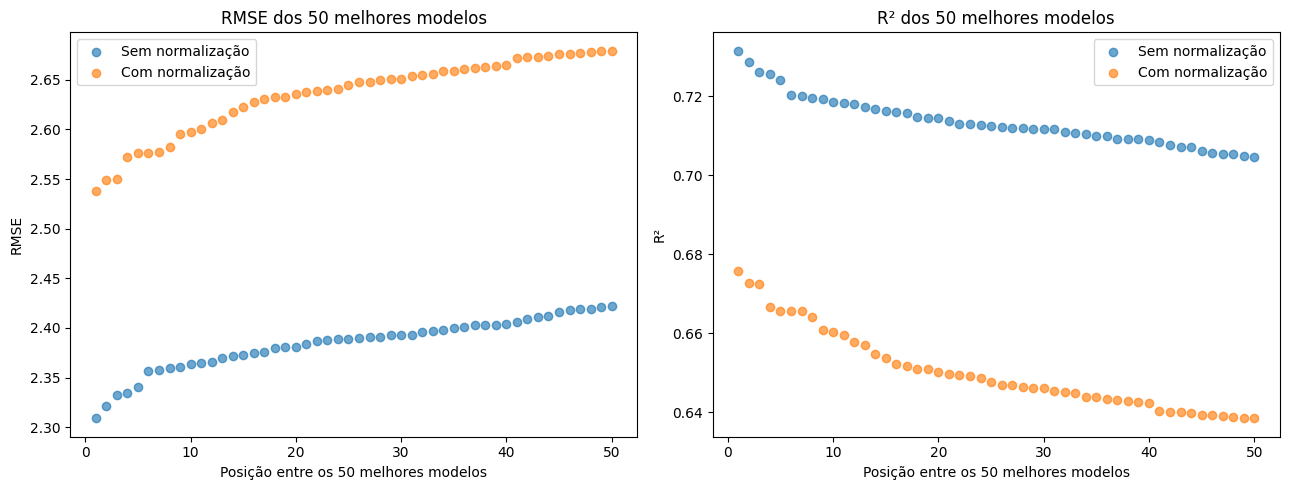

Melhor RMSE sem normalização: 2.309
Melhor RMSE com normalização: 2.538
Maior R² sem normalização: 0.731
Maior R² com normalização: 0.676


In [17]:
import re
import ast
import matplotlib.pyplot as plt

def resultados_para_dataframe(dicionario, normalizado=False):
    registros = []

    padrao = re.compile(
        r"COMBINAÇÃO_ATRIBUTOS = (\[.*?\]) \|\s*"
        r"NUM_VIZINHOS = (\d+) \| DISTANCIA = (\d+) \| PESOS = (\w+)",
        re.DOTALL
    )

    for configuracao, (rmse, r2) in dicionario.items():
        correspondencia = padrao.search(configuracao)

        if correspondencia is None:
            continue

        atributos = ast.literal_eval(correspondencia.group(1))
        k = int(correspondencia.group(2))
        p = int(correspondencia.group(3))
        pesos = correspondencia.group(4)

        registros.append({
            "atributos": atributos,
            "n_atributos": len(atributos),
            "k": k,
            "p": p,
            "pesos": pesos,
            "RMSE": rmse,
            "R2": r2,
            "normalizado": normalizado,
            "possui_Mjob_novo": "Mjob_novo" in atributos
        })

    return pd.DataFrame(registros)

resultados = resultados_para_dataframe(avaliando_os_modelos, False)
resultados_norm = resultados_para_dataframe(avaliando_os_modelos_norm, True)

top50 = resultados.sort_values("RMSE").head(50).reset_index(drop=True)
top50_norm = resultados_norm.sort_values("RMSE").head(50).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(
    range(1, 51), top50["RMSE"],
    alpha=0.65, label="Sem normalização"
)
axes[0].scatter(
    range(1, 51), top50_norm["RMSE"],
    alpha=0.65, label="Com normalização"
)
axes[0].set_xlabel("Posição entre os 50 melhores modelos")
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE dos 50 melhores modelos")
axes[0].legend()

axes[1].scatter(
    range(1, 51), top50["R2"],
    alpha=0.65, label="Sem normalização"
)
axes[1].scatter(
    range(1, 51), top50_norm["R2"],
    alpha=0.65, label="Com normalização"
)
axes[1].set_xlabel("Posição entre os 50 melhores modelos")
axes[1].set_ylabel("R²")
axes[1].set_title("R² dos 50 melhores modelos")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Melhor RMSE sem normalização: {top50.loc[0, "RMSE"]:.3f}")
print(f"Melhor RMSE com normalização: {top50_norm.loc[0, "RMSE"]:.3f}")
print(f"Maior R² sem normalização: {top50["R2"].max():.3f}")
print(f"Maior R² com normalização: {top50_norm["R2"].max():.3f}")


<div style="text-align: justify; max-width: 96%">
O gráfico permite verificar que a vantagem observada nos cinco melhores modelos também aparece quando se considera um conjunto maior de configurações. Dado que os pontos correspondentes aos modelos não normalizados permaneceram, de maneira geral, com RMSE maior e R² menor, verifica-se que a normalização piorou o desempenho não depende apenas de poucas configurações específicas. Dessa forma, é válido tentar observar correlações entre os atributos e o <i>target</i> (processo que será feito utilizando a <a href="https://www.sciencedirect.com/topics/computer-science/pearson-correlation">Correlação de Pearson</a> como uma medida exploratória):
</div>

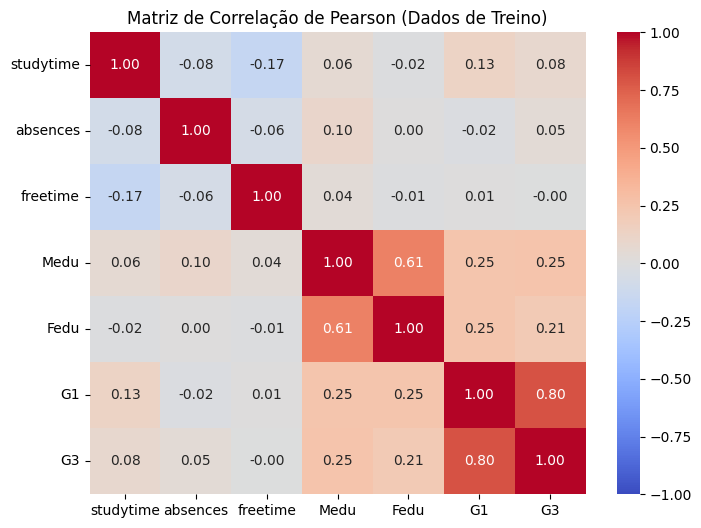

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

colunas_interesse = ['studytime','absences','freetime','Medu','Fedu','G1'] + TARGET
correlacao = df_treino[colunas_interesse].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação de Pearson (Dados de Treino)")
plt.show()

<div style="text-align: justify; max-width: 96%">
Finalmente, agora há evidência estatística para apontar que piora no desempenho é pode ser  justificada por um fenômeno comum aos algoritmos baseados em distâncias. No formato sem normalização, o atributo numérico com a maior amplitude original de variação era justamente a nota do primeiro período (<code>G1</code>, de 0 a 20). Essa escala maior tornava o atributo matematicamente dominante no cálculo do &#119896;-NN. Conforme demonstrado pelo coeficiente linear de Pearson, <code>G1</code> é, de longe, a variável com a correlação mais poderosa em relação ao alvo final <code>G3</code>. Normalizar fez com que os outros atributos passassem a influenciar mais a decisão final (o que não é coerente com o observado pelos gráficos de correlação)

Portanto, a dominância desproporcional conferida a ele pela falta de escala coincidia exatamente com a sua verdadeira importância no mundo real. Ao normalizar a base, atributos com baixa taxa correlativa (como as profissões e as educações materna e paterna) ganharam um poder de influência maior no cálculo do que a variável escolar. Isso serviu de forma a diluir a influência do atributo principal, afastando espacialmente alunos que seriam semelhantes - o que é conflitante com a premissa inicial do algoritmo &#119896;-NN, consequentemente abalando a precisão das previsões.


</div>

### O impacto do número de vizinhos (&#119896;)


<div style="text-align: justify; max-width: 96%">
Por fim, cabe visualizar a relação do hiperparâmetro &#119896; com o desempenho final, conforme estipulado na introdução da seção de resultados. A expectativa teórica é que um &#119896; muito baixo gere <i>overfitting</i> (o modelo se ajusta a ruídos isolados), e um &#119896; muito alto cause <i>underfitting</i> (o modelo suaviza demais as previsões, tendendo à média geral). Para observar isso, isolaremos a melhor combinação de atributos e distancia encontrada e variaremos apenas o &#119896;:
</div>

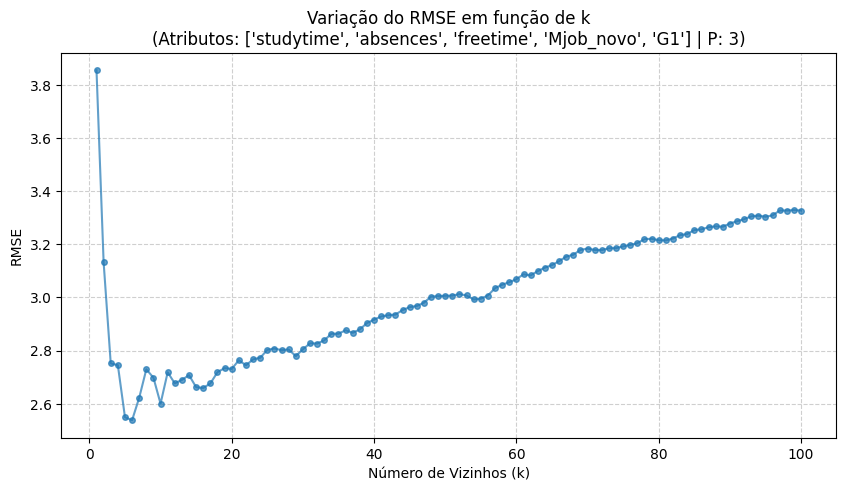

Menor RMSE observado no gráfico ocorre com k = 6


In [19]:
import numpy as np

# Extraindo os parâmetros do melhor modelo (índice 0 dos dados normalizados)
melhor_config = top50_norm.iloc[0]
melhores_atributos = melhor_config['atributos']
melhor_peso = melhor_config['pesos']
melhor_distancia = melhor_config['p']

k_valores = []
rmse_valores = []

for k in NUM_VIZINHOS:
    chave = f'COMBINAÇÃO_ATRIBUTOS = {melhores_atributos} |\n NUM_VIZINHOS = {k} | DISTANCIA = {melhor_distancia} | PESOS = {melhor_peso}'
    if chave in avaliando_os_modelos_norm:
        k_valores.append(k)
        rmse_valores.append(avaliando_os_modelos_norm[chave][0])

plt.figure(figsize=(10, 5))
plt.plot(k_valores, rmse_valores, marker='o', linestyle='-', markersize=4, alpha=0.7)
plt.xlabel("Número de Vizinhos (k)")
plt.ylabel("RMSE")
plt.title(f"Variação do RMSE em função de k\n(Atributos: {melhores_atributos} | P: {melhor_distancia})")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

melhor_k_grafico = k_valores[np.argmin(rmse_valores)]
print(f"Menor RMSE observado no gráfico ocorre com k = {melhor_k_grafico}")

<div style="text-align: justify; max-width: 96%">
De fato, a premissa teórica do equilíbrio viés-variância pode ser observada claramente. Nota-se que o RMSE cai acentuadamente ao sair de um  igual &#119896; a 1 (diminuindo o <i>overfitting</i>) até encontrar um ponto ótimo, a partir do qual o erro volta a subir lentamente à medida que a vizinhança se torna excessivamente grande e genérica (aumentando o <i>underfitting</i>)
</div>

## Conclusão

<div style="text-align: justify; max-width: 96%">
Em suma, a formulação deste modelo preditivo colaborou para mostrar a complexidade e a ausência de princípios universais no Aprendizado de Máquina. O algoritmo &#119896;-NN executa seu poder inferencial principalmente baseando-se na relação espacial dos atributos, tornando o ajuste fino dos hiperparâmetros (como a funçãp de distância e o número de vizinhos) vital no desenvolvimento de um modelo prático.

A mais significativa contribuição deste processo específico de modelagem residiu no aprendizado quanto ao pré-processamento. Esse experimento provou que o peso natural e a diferença absoluta de escala podem, às vezes, refletir perfeitamente a importância real intrínseca dos atributos - o que, novamente, <b>só é revelado mediante análise estatística e pré-processamento</b>. Notou-se e discutiu-se que forçar distribuições normais (isto é, sem necessariamente ter entendido o proquê disso) diluiu o poder preditivo do atributo (<code>G1</code>) sob o ruído de variáveis secundárias.

Assim, observou-se uma das vantagens fundamentais dos modelos de Machine Learning do algortimo &#119896;-NN: sua interpretabilidade! A variação dos hiperparâmetros foi discutida exaustivamente e foi por meio dessa análise nada rasa que obteve-se um modelo com performance satisfatória (como, também, houveram desempenhos inesperados, mas que renderam discussões interessantes).
</div>

## Descrição do uso de IA neste trabalho

<div style="text-align: justify; max-width: 96%">
Ferramentas de inteligência artificial foram utilizadas nesse notebook para os seguintes fins:
<ul>
    <li><b>Formatação das referências -</b> submeteu-se o conjunto final bibliográfico a um agente de inteligência artificial visando adequação às regras da ABNT;</li>
    <li><b>Rápida revisão -</b> as ferramentas apoiaram na revisão gramatical, de coesão textual e na manutenção de impessoalidade contínua no discurso presente no notebook.</li>
    <li><b>Colaboração na criação dos gráficos - </b> para conseguir deixar a disposição dos gráficos de forma visualmente atraente (por exemplo, usei de ferramentas de IA para utilizar os métodos como o <code>subplot</code>)
</ul>
</div>

## Referências

<div style="text-align: justify; max-width: 96%">

<ul>
<li>DATACAMP. <i>Curse of dimensionality in machine learning</i>. Disponível em: <a href="https://www.datacamp.com/pt/blog/curse-of-dimensionality-machine-learning">https://www.datacamp.com/pt/blog/curse-of-dimensionality-machine-learning</a>. Acesso em: 11 set. 2026.</li><br>

<li>DATACAMP. <i>Minkowski distance</i>. Disponível em: <a href="https://www.datacamp.com/pt/tutorial/minkowski-distance">https://www.datacamp.com/pt/tutorial/minkowski-distance</a>. Acesso em: 11 set. 2026.</li><br>

<li>DEVMEDIA. <i>HTML Entities</i>. Disponível em: <a href="https://arquivo.devmedia.com.br/artigos/devmedia/html-entities.html">https://arquivo.devmedia.com.br/artigos/devmedia/html-entities.html</a>. Acesso em: 11 set. 2026.</li><br>

<li>GOOGLE. <i>Machine Learning Crash Course: loss</i>. Disponível em: <a href="https://developers.google.com/machine-learning/crash-course/linear-regression/loss?hl=pt-br">https://developers.google.com/machine-learning/crash-course/linear-regression/loss?hl=pt-br</a>. Acesso em: 11 set. 2026.</li><br>

<li>IBM. <i>Feature selection</i>. Disponível em: <a href="https://www.ibm.com/think/topics/feature-selection">https://www.ibm.com/think/topics/feature-selection</a>. Acesso em: 11 set. 2026.</li><br>

<li>IBM. <i>K-Nearest Neighbors (KNN)</i>. Disponível em: <a href="https://www.ibm.com/br-pt/think/topics/knn#684929711">https://www.ibm.com/br-pt/think/topics/knn#684929711</a>. Acesso em: 11 set. 2026.</li><br>

<li>KAGGLE. <i>Student Performance Data Set</i>. Baseado no repositório UCI. Disponível em: <a href="https://www.kaggle.com/datasets/imkrkannan/student-performance-data-set-y-uci">https://www.kaggle.com/datasets/imkrkannan/student-performance-data-set-y-uci</a>. Acesso em: 11 set. 2026.</li><br>

<li>SCIENCE DIRECT. <i>Pearson Correlation</i>. Disponível em: <a href="https://www.sciencedirect.com/topics/computer-science/pearson-correlation">https://www.sciencedirect.com/topics/computer-science/pearson-correlation</a>. Acesso em: 11 set. 2026.</li><br>

<li>SCIKIT-LEARN. <i>KNeighborsRegressor</i>. Disponível em: <a href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html">https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html</a>. Acesso em: 11 set. 2026.</li><br>

<li>WIKIPEDIA CONTRIBUTORS. <i>Minkowski distance</i>. Wikipedia, The Free Encyclopedia. Disponível em: <a href="https://en.wikipedia.org/wiki/Minkowski_distance">https://en.wikipedia.org/wiki/Minkowski_distance</a>. Acesso em: 11 set. 2026.</li><br>
</ul>

</div>